# APSRTC Dataset Analysis

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [46]:
data = pd.read_csv('./APSRTC_Transport_Data.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   bus_id                1000 non-null   object 
 1   route                 1000 non-null   object 
 2   bus_type              1000 non-null   object 
 3   depot                 1000 non-null   object 
 4   date                  1000 non-null   object 
 5   capacity              1000 non-null   int64  
 6   passengers            1000 non-null   int64  
 7   occupancy_rate        1000 non-null   float64
 8   distance_km           1000 non-null   float64
 9   fare_per_passenger    1000 non-null   float64
 10  revenue               1000 non-null   float64
 11  fuel_consumed_liters  1000 non-null   float64
 12  month                 1000 non-null   object 
 13  day_of_week           1000 non-null   object 
dtypes: float64(5), int64(2), object(7)
memory usage: 109.5+ KB


In [47]:
df = data.copy()
df.head()

,bus_id,route,bus_type,depot,date,capacity,passengers,occupancy_rate,distance_km,fare_per_passenger,revenue,fuel_consumed_liters,month,day_of_week
0,AP0001,Kurnool-Hyderabad,Volvo AC,Guntur,2024-11-26,49,32,65.77,326.58,908.75,29079.96,75.73,November,Tuesday
1,AP0002,Anantapur-Bangalore,Sleeper,Tirupati,2024-10-03,36,14,41.42,291.91,770.66,10789.30,71.55,October,Thursday
2,AP0003,Hyderabad-Vijayawada,Volvo AC,Vijayawada,2024-07-06,49,43,89.26,238.41,277.49,11932.08,47.85,July,Saturday
3,AP0004,Eluru-Hyderabad,Semi-Sleeper,Kurnool,2024-11-02,63,52,83.97,347.55,199.64,10381.38,72.64,November,Saturday
4,AP0005,Kurnool-Hyderabad,Sleeper,Hyderabad,2024-09-20,44,31,70.62,444.88,591.89,18348.44,77.17,September,Friday


In [48]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

In [49]:
df['from_location'] = df['route'].apply(lambda x: x.split("-")[0])
df['to_location'] = df['route'].apply(lambda x: x.split("-")[1])

In [50]:
df.to_csv('./APSRTC_Transport_Data_Updated.csv', index=False)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   bus_id                1000 non-null   object        
 1   route                 1000 non-null   object        
 2   bus_type              1000 non-null   object        
 3   depot                 1000 non-null   object        
 4   date                  1000 non-null   datetime64[ns]
 5   capacity              1000 non-null   int64         
 6   passengers            1000 non-null   int64         
 7   occupancy_rate        1000 non-null   float64       
 8   distance_km           1000 non-null   float64       
 9   fare_per_passenger    1000 non-null   float64       
 10  revenue               1000 non-null   float64       
 11  fuel_consumed_liters  1000 non-null   float64       
 12  month                 1000 non-null   object        
 13  day_of_week        

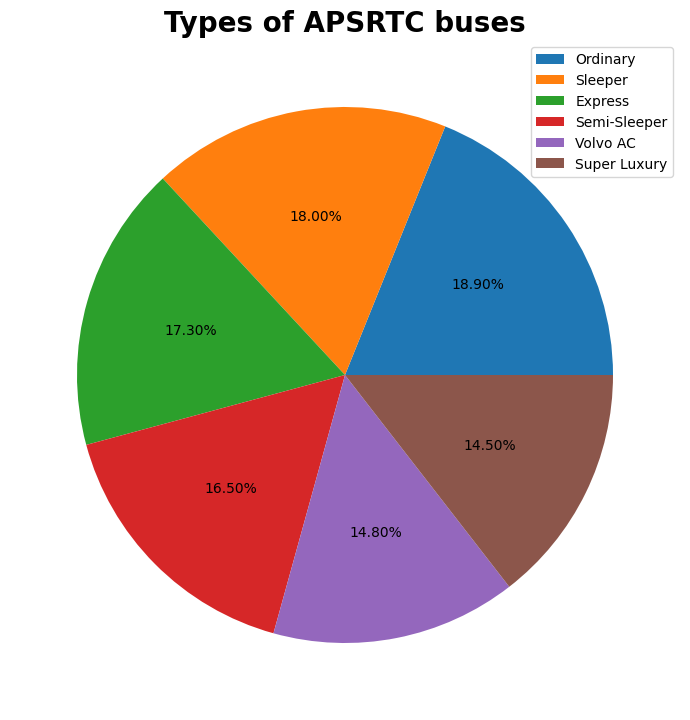

In [ ]:
# Pie Chart to represent the different types of buses in this dataset

bus_types = np.array(df['bus_type'].value_counts().index)
bus_types_data = np.array(df['bus_type'].value_counts().values)

plt.figure(figsize=(7,8))
plt.title("Types of APSRTC buses", fontweight="bold", fontsize=20)

plt.pie(bus_types_data, autopct='%1.2f%%')
plt.legend(bus_types, loc="best")

plt.tight_layout()
plt.show()

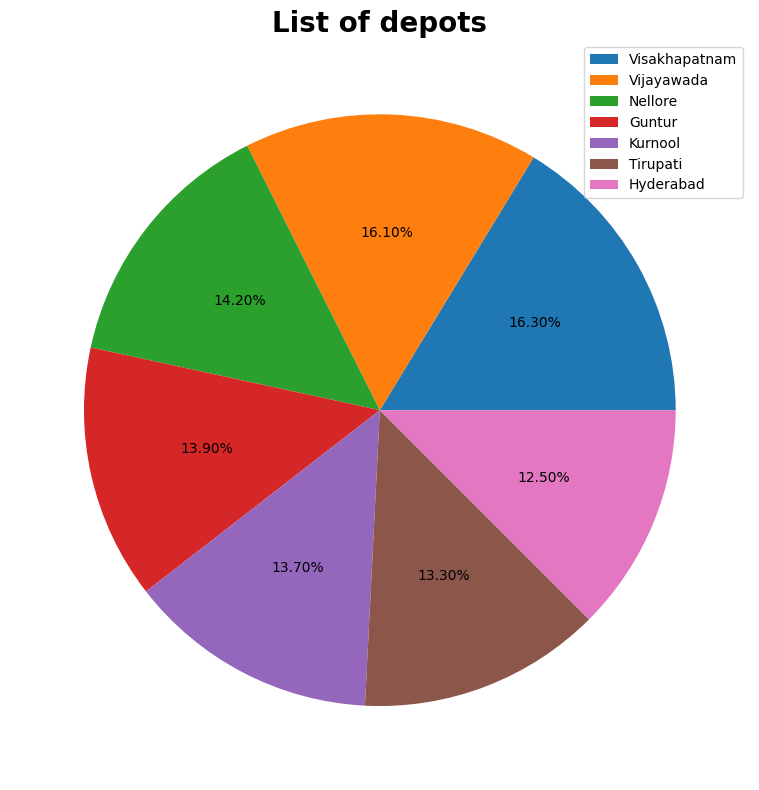

In [ ]:
# Pie Chart to represent the different depots used by buses in this dataset

depots = np.array(df['depot'].value_counts().index)
depots_data = np.array(df['depot'].value_counts().values)

plt.figure(figsize=(10,8))
plt.title("List of depots", fontweight="bold", fontsize=20)

plt.pie(depots_data, autopct='%1.2f%%')
plt.legend(depots, loc="best")

plt.tight_layout()
plt.show()

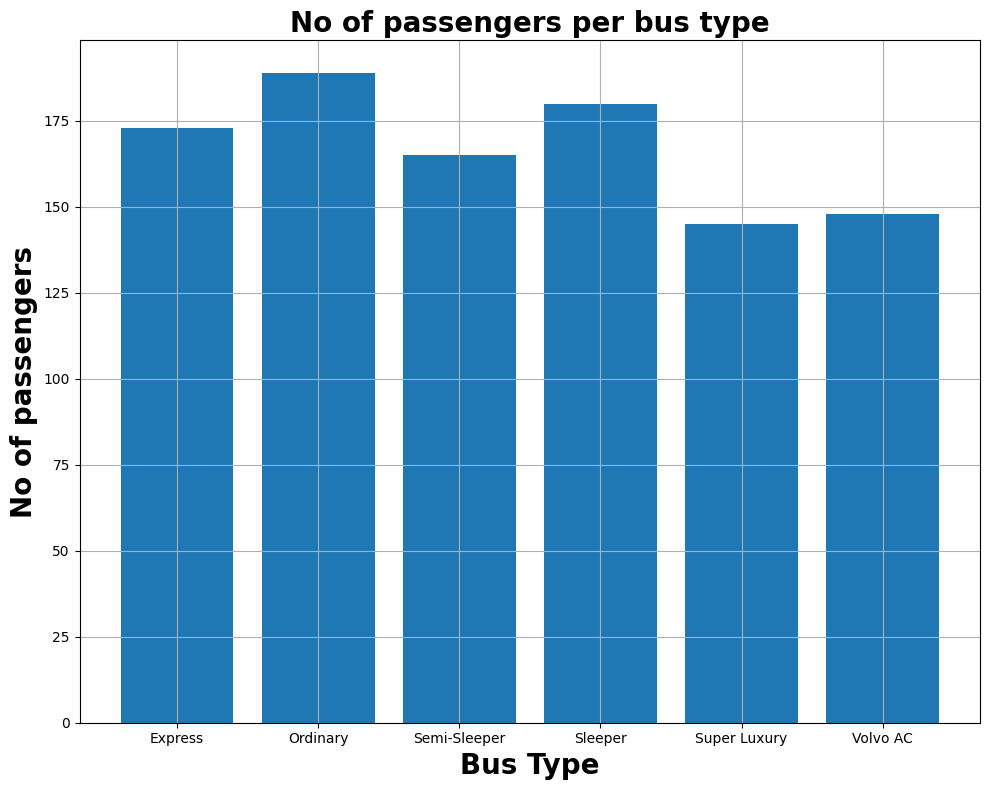

In [145]:
bt_labels = df.groupby('bus_type')['passengers'].count().index
bt_values = df.groupby('bus_type')['passengers'].count().values

plt.figure(figsize=(10,8))

plt.title("No of passengers per bus type", fontweight="bold", fontsize=20)
plt.xlabel("Bus Type", fontweight="bold", fontsize=20)
plt.ylabel("No of passengers", fontweight="bold", fontsize=20)

plt.bar(bt_labels, bt_values)
plt.grid()

plt.tight_layout()
plt.show()

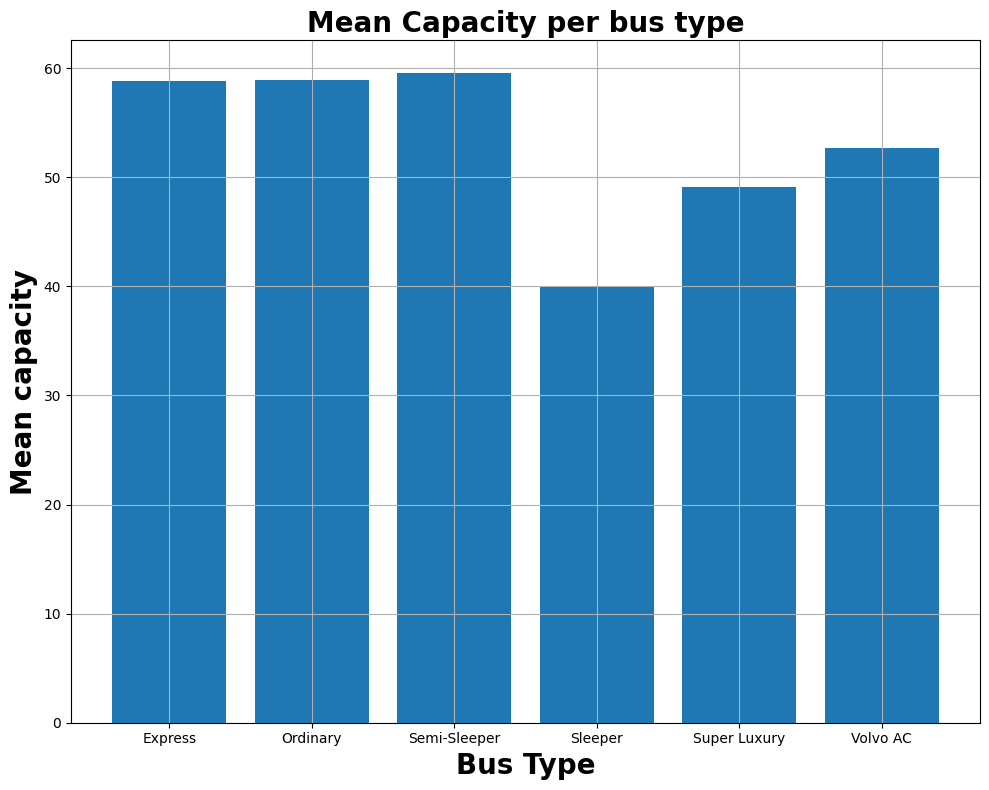

In [144]:
btc_labels = np.array(df.groupby('bus_type')['capacity'].mean().index)
btc_values = np.array(df.groupby('bus_type')['capacity'].mean().values)

plt.figure(figsize=(10,8))

plt.title("Mean Capacity per bus type", fontweight="bold", fontsize=20)
plt.xlabel("Bus Type", fontweight="bold", fontsize=20)
plt.ylabel("Mean capacity", fontweight="bold", fontsize=20)

plt.bar(btc_labels, btc_values)
plt.grid()

plt.tight_layout()
plt.show()

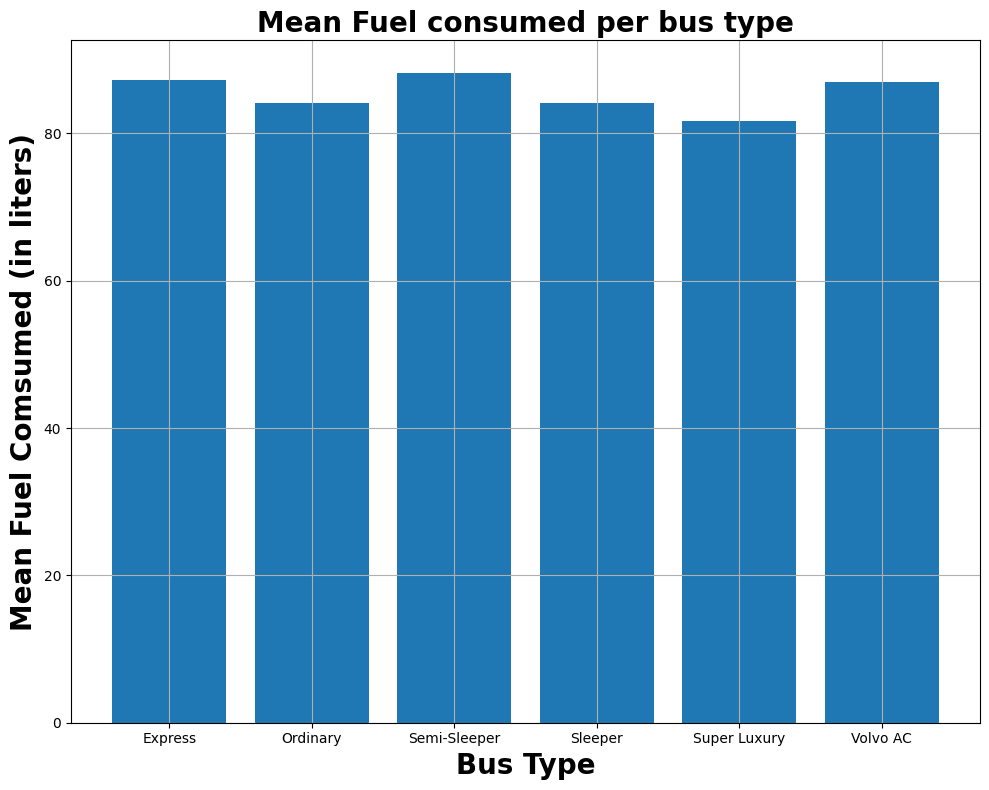

In [143]:
btc_labels = np.array(df.groupby('bus_type')['fuel_consumed_liters'].mean().index)
btc_values = np.array(df.groupby('bus_type')['fuel_consumed_liters'].mean().values)

plt.figure(figsize=(10,8))

plt.title("Mean Fuel consumed per bus type", fontweight="bold", fontsize=20)
plt.xlabel("Bus Type", fontweight="bold", fontsize=20)
plt.ylabel("Mean Fuel Comsumed (in liters)", fontweight="bold", fontsize=20)

plt.bar(btc_labels, btc_values)
plt.grid()

plt.tight_layout()
plt.show()